In [2]:
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import matplotlib.gridspec as gridspec
import matplotlib
%matplotlib inline
import config as cfg


def pseudo_model(x, sigma=0.1):
    y = x
    y = y + (y - 0.5)/10
    noise = np.random.normal(0, sigma, len(x))
    #print(noise)
    y = y + noise
    y = np.clip(y, 0, 1)

    

    #y = np.clip(y, 0, 1)

    return y


preds_dict = {}
true_dict = {}

lr_preds_dict = {}
lr_true_dict = {}

for endpoint in cfg.endpoint_list:
    true_dict[endpoint] = np.random.randint(0, 2, 100)
    preds_dict[endpoint] = pseudo_model(true_dict[endpoint], sigma=1)

    lr_preds_dict[endpoint] = np.random.rand(100)
    lr_true_dict[endpoint] = np.random.randint(0, 2, 100)



In [1]:
pip install einops

   ---------------------------------------- 0.0/43.2 kB ? eta -:--:--
   ------------------------------------- -- 41.0/43.2 kB 960.0 kB/s eta 0:00:01
   ---------------------------------------- 43.2/43.2 kB 1.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
trial_path = "/home/d.c.macrae@mydre.org/Documents/DL_NTCP_Multitox/experiments/MixUp_ResNet/20240425_075304_5_101_28_resnet_lrelu_params_408325_auc_tr_0.714_val_0.697_avg_tr_0.701_val_0.693/"

DL_preds = pd.read_csv(os.path.join(trial_path, "resnet_lrelu_all_outputs.csv"), delimiter=";")
LR_preds = pd.read_csv(os.path.join(trial_path, "lr_all_outputs.csv"), delimiter=";")

DL_preds = DL_preds[DL_preds["Mode"] == "val"]
LR_preds = LR_preds[LR_preds["Mode"] == "val"]


for endpoint in cfg.endpoint_list:
    preds_dict[endpoint] = DL_preds[endpoint+"_pred"]
    true_dict[endpoint] = DL_preds[endpoint+"_true"]

    lr_preds_dict[endpoint] = LR_preds[endpoint+"_pred"]
    lr_true_dict[endpoint] = LR_preds[endpoint+"_true"]




In [4]:
import colorsys

def scale_lightness(rgb, scale_l):
    # convert rgb to hls
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # manipulate h, l, s values and return as rgb
    return colorsys.hls_to_rgb(h, min(1, l * scale_l), s)

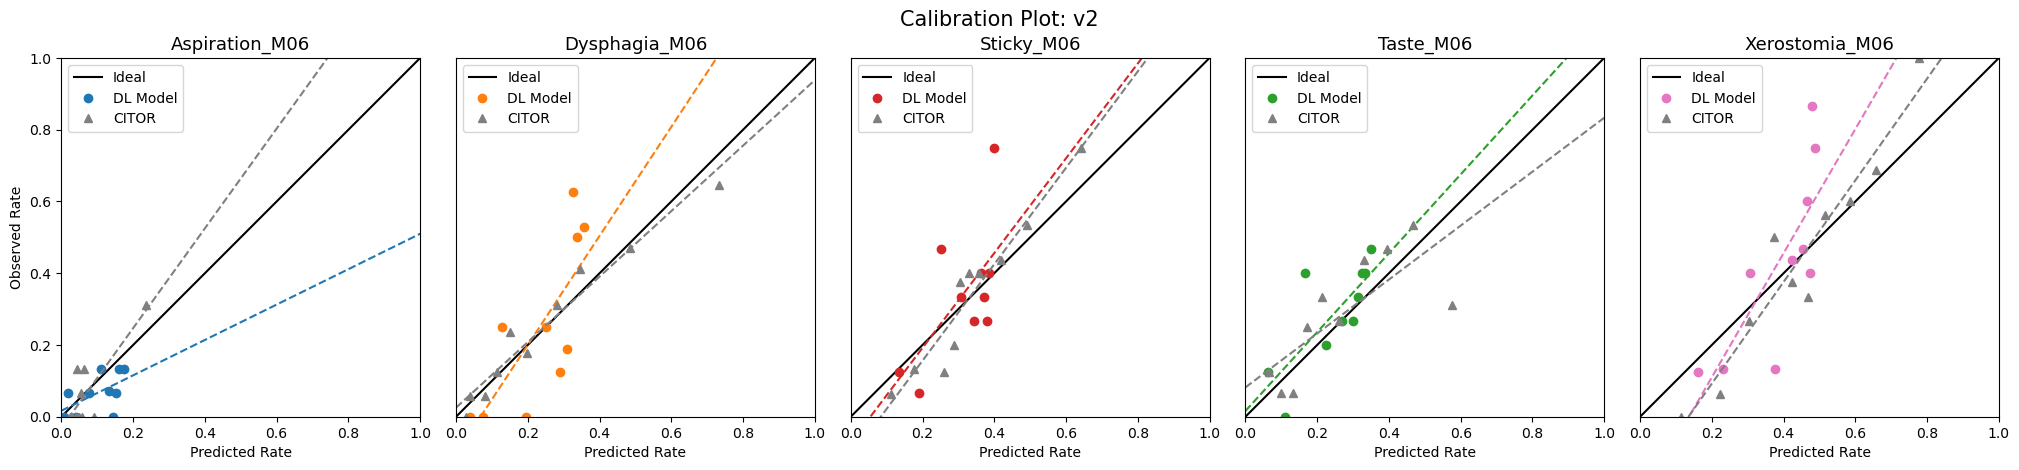

In [5]:
%matplotlib inline
def make_calibration_plots(config, predictions_dict, true_labels_dict, lr_predictions_dict, lr_true_labels_dict, set_name, filename=None):
    """
    Makes a calivration plot using a set predicitons and true labels. The predictions are split into 10 bins for this.
    The plot is then saved to a file if a `filename` is provided.
    Args:
        config: a ConfigObject.
        predictions_dict: a dictionary of lists of predictions for each endpoint.
        true_labels_dict: a dictionary of lists of true labels for each endpoint.
        set_name: a string, the name of the set (e.g. 'train', 'val', 'test') to be used in the title of the plot.
        filename: a string, the name of the file to save the plot to.
    Returns:
        None
    """
    colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']

    num_endpoints = len(config.endpoint_list)
    row_count = 1
    fig_width = 5 * num_endpoints 
    fig_height = 5 * row_count

    # Create a gridspec to add a colorbar axis
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(
        row_count,
        num_endpoints,
        width_ratios=[1] * num_endpoints,
        hspace=0.,
        wspace=0.1,
        figure=fig,
    )

    # Create title
    fig.suptitle("Calibration Plot: {}".format(set_name), fontsize=15, y=0.95)

    # Create subplots
    axs = [
        [plt.subplot(gs[i, j]) for j in range(num_endpoints)] for i in range(row_count)
    ]

    x = [0,1]
    y = [0,1]

    for i in range(row_count):
        for j in range(num_endpoints):
            axs[i][j].set_aspect("equal")
            if i != row_count - 1:
                axs[i][j].xaxis.set_visible(False)
            else:
                axs[i][j].set_xlabel("Predicted Rate")
            
            if j != 0:
                axs[i][j].yaxis.set_visible(False)
            else:
                axs[i][j].set_ylabel("Observed Rate")

            axs[i][j].set_xlim(0, 1)
            axs[i][j].set_ylim(0, 1)

            axs[i][j].plot([0, 1], [0, 1], "black", label="Ideal") # plot the ideal line


    for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
        
        y_pred = predictions_dict[endpoint]
        y_true = true_labels_dict[endpoint]      # NOTE add .cpu().numpy() to these two lines again later

        mask = [True if x in config.valid_endpoint_values else False for x in y_true]

        y_true = y_true[mask]
        y_pred = y_pred[mask]

        fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=10, strategy="quantile")

        coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
        linear_fit = np.poly1d(coef)

        # plot the points (scatter)
        col_rgb = matplotlib.colors.ColorConverter().to_rgb(colours[idx])
        color = scale_lightness(col_rgb, 1)
        

        ax.plot(mean_predicted_value, fraction_of_positives, 'o', label="DL Model", color=color)
        # plot the best fit line
        ax.plot(x, linear_fit(y), '--',   color=color)
        ax.set_title(endpoint, fontdict={'fontsize': 13})
        
        #ax.plot(mean_predicted_value, fraction_of_positives, '-', label=endpoint,  color=colours[idx])

    #     #plt.plot(mean_predicted_value, fraction_of_positives, 'o-', color=colours[idx])
    for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
        
        y_pred = lr_predictions_dict[endpoint]
        y_true = lr_true_labels_dict[endpoint]      # NOTE add .cpu().numpy() to these two lines again later

        mask = [True if x in config.valid_endpoint_values else False for x in y_true]

        y_true = y_true[mask]
        y_pred = y_pred[mask]

        fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=10, strategy="quantile")

        coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
        linear_fit = np.poly1d(coef)

        # Make a darker color
        col_rgb = matplotlib.colors.ColorConverter().to_rgb(colours[idx])
        color = scale_lightness(col_rgb, 0.5)
        color = 'gray'

        # plot the points (scatter)
        ax.plot(mean_predicted_value, fraction_of_positives, '^', label="CITOR",color=color, alpha=1)
        # plot the best fit line
        ax.plot(x, linear_fit(y), '--', color=color, alpha=1)
        ax.legend()

    if filename is not None:
        plt.savefig(filename)
    plt.show()


make_calibration_plots(cfg, preds_dict, true_dict, lr_preds_dict, lr_true_dict, set_name="v2")

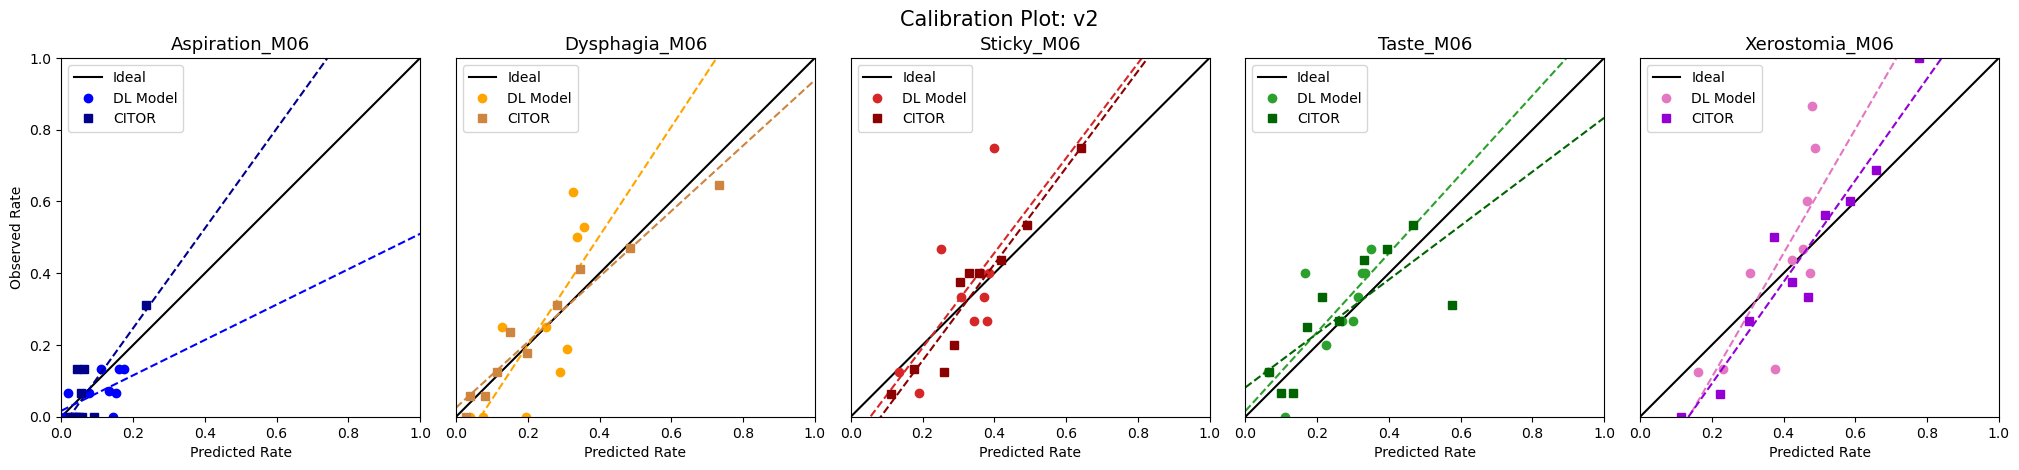

In [6]:
%matplotlib inline
def make_calibration_plots(config, predictions_dict, true_labels_dict, lr_predictions_dict, lr_true_labels_dict, set_name, filename=None):
    """
    Makes a calivration plot using a set predicitons and true labels. The predictions are split into 10 bins for this.
    The plot is then saved to a file if a `filename` is provided.
    Args:
        config: a ConfigObject.
        predictions_dict: a dictionary of lists of predictions for each endpoint.
        true_labels_dict: a dictionary of lists of true labels for each endpoint.
        set_name: a string, the name of the set (e.g. 'train', 'val', 'test') to be used in the title of the plot.
        filename: a string, the name of the file to save the plot to.
    Returns:
        None
    """
    colours = ['blue', 'orange', 'tab:red', 'tab:green', 'tab:pink', 'magenta', 'tab:brown', 'tab:cyan']
    lr_colors = ["darkblue", 'peru', 'darkred', 'darkgreen', 'darkviolet', 'darkmagenta']

    num_endpoints = len(config.endpoint_list)
    row_count = 1
    fig_width = 5 * num_endpoints 
    fig_height = 5 * row_count

    # Create a gridspec to add a colorbar axis
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(
        row_count,
        num_endpoints,
        width_ratios=[1] * num_endpoints,
        hspace=0.,
        wspace=0.1,
        figure=fig,
    )

    # Create title
    fig.suptitle("Calibration Plot: {}".format(set_name), fontsize=15, y=0.95)

    # Create subplots
    axs = [
        [plt.subplot(gs[i, j]) for j in range(num_endpoints)] for i in range(row_count)
    ]

    x = [0,1]
    y = [0,1]

    for i in range(row_count):
        for j in range(num_endpoints):
            axs[i][j].set_aspect("equal")
            if i != row_count - 1:
                axs[i][j].xaxis.set_visible(False)
            else:
                axs[i][j].set_xlabel("Predicted Rate")
            
            if j != 0:
                axs[i][j].yaxis.set_visible(False)
            else:
                axs[i][j].set_ylabel("Observed Rate")

            axs[i][j].set_xlim(0, 1)
            axs[i][j].set_ylim(0, 1)

            axs[i][j].plot([0, 1], [0, 1], "black", label="Ideal") # plot the ideal line


    for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
        
        y_pred = predictions_dict[endpoint]
        y_true = true_labels_dict[endpoint]      # NOTE add .cpu().numpy() to these two lines again later

        mask = [True if x in config.valid_endpoint_values else False for x in y_true]

        y_true = y_true[mask]
        y_pred = y_pred[mask]

        fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=10, strategy="quantile")

        coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
        linear_fit = np.poly1d(coef)

        # plot the points (scatter)
        col_rgb = matplotlib.colors.ColorConverter().to_rgb(colours[idx])
        color = scale_lightness(col_rgb, 1)
        

        ax.plot(mean_predicted_value, fraction_of_positives, 'o', label="DL Model", color=color)
        # plot the best fit line
        ax.plot(x, linear_fit(y), '--',   color=color)
        ax.set_title(endpoint, fontdict={'fontsize': 13})
        
        #ax.plot(mean_predicted_value, fraction_of_positives, '-', label=endpoint,  color=colours[idx])

    #     #plt.plot(mean_predicted_value, fraction_of_positives, 'o-', color=colours[idx])
    for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
        
        y_pred = lr_predictions_dict[endpoint]
        y_true = lr_true_labels_dict[endpoint]      # NOTE add .cpu().numpy() to these two lines again later

        mask = [True if x in config.valid_endpoint_values else False for x in y_true]

        y_true = y_true[mask]
        y_pred = y_pred[mask]

        fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=10, strategy="quantile")

        coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
        linear_fit = np.poly1d(coef)

        # Make a darker color
        col_rgb = matplotlib.colors.ColorConverter().to_rgb(lr_colors[idx])
        color = scale_lightness(col_rgb, 1)
        #color = 'gray'

        # plot the points (scatter)
        ax.plot(mean_predicted_value, fraction_of_positives, 's', label="CITOR",color=color, alpha=1)
        # plot the best fit line
        ax.plot(x, linear_fit(y), '--', color=color, alpha=1)
        ax.legend()

    if filename is not None:
        plt.savefig(filename)
    plt.show()


make_calibration_plots(cfg, preds_dict, true_dict, lr_preds_dict, lr_true_dict, set_name="v2")

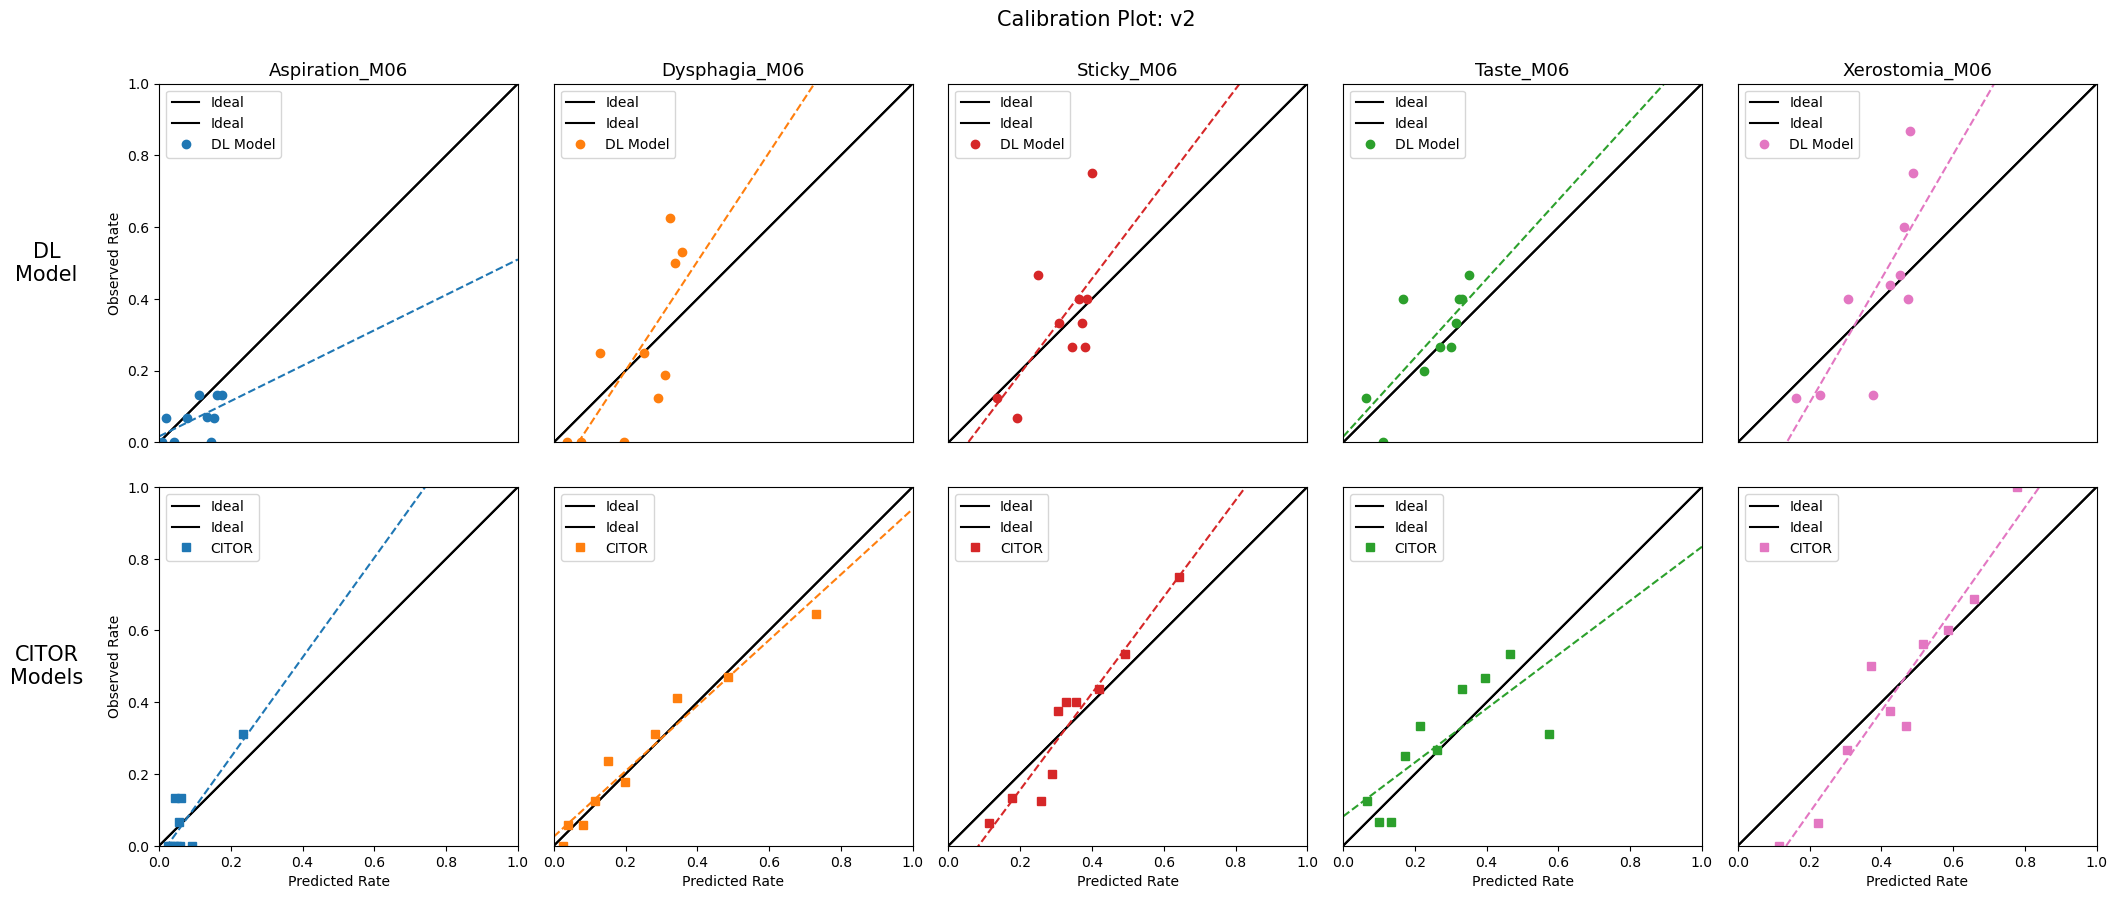

In [20]:
%matplotlib inline
def make_calibration_plots(config, predictions_dict, true_labels_dict, lr_predictions_dict, lr_true_labels_dict, set_name, filename=None):
    """
    Makes a calivration plot using a set predicitons and true labels. The predictions are split into 10 bins for this.
    The plot is then saved to a file if a `filename` is provided.
    Args:
        config: a ConfigObject.
        predictions_dict: a dictionary of lists of predictions for each endpoint.
        true_labels_dict: a dictionary of lists of true labels for each endpoint.
        set_name: a string, the name of the set (e.g. 'train', 'val', 'test') to be used in the title of the plot.
        filename: a string, the name of the file to save the plot to.
    Returns:
        None
    """
    colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']

    num_endpoints = len(config.endpoint_list)
    row_count = 2
    fig_width = 5 * num_endpoints 
    fig_height = 5 * row_count

    # Create a gridspec to add a colorbar axis
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(
        row_count,
        num_endpoints,
        width_ratios=[1] * num_endpoints,
        hspace=0.1,
        wspace=0.1,
        figure=fig,
    )

    # Create title
    fig.suptitle("Calibration Plot: {}".format(set_name), fontsize=15, y=0.95)

    # Create subplots
    axs = [
        [plt.subplot(gs[i, j]) for j in range(num_endpoints)] for i in range(row_count)
    ]

    labels = ["DL\nModel", "CITOR\nModels"]

    for i in range(row_count):
        for j in range(num_endpoints):
            axs[i][j].set_aspect("equal")
            if i != row_count - 1:
                axs[i][j].xaxis.set_visible(False)
            else:
                axs[i][j].set_xlabel("Predicted Rate")
            
            if j != 0:
                axs[i][j].yaxis.set_visible(False)
            else:
                axs[i][j].set_ylabel("Observed Rate")
                axs[i][j].annotate(
                    labels[i],
                    xy=(0, 0.5),
                    xytext=(-axs[i][j].yaxis.labelpad - 40, 0),
                    xycoords=axs[i][j].yaxis.label,
                    textcoords="offset points",
                    size=15,
                    ha="center",
                    va="center",
                )

            axs[i][j].set_xlim(0, 1)
            axs[i][j].set_ylim(0, 1)

            axs[i][j].plot([0, 1], [0, 1], "black", label="Ideal") # plot the ideal line


    for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
        calibration_subplot(config, ax, endpoint, predictions_dict[endpoint], true_labels_dict[endpoint], color=colours[idx], DL_model=True)
        
        
    for idx, (ax, endpoint) in enumerate(zip(axs[1], config.endpoint_list)):
        calibration_subplot(config, ax, endpoint, lr_predictions_dict[endpoint], lr_true_labels_dict[endpoint], color=colours[idx], DL_model=False)

    if filename is not None:
        plt.savefig(filename)
    plt.show()





make_calibration_plots(cfg, preds_dict, true_dict, lr_preds_dict, lr_true_dict, set_name="v2")

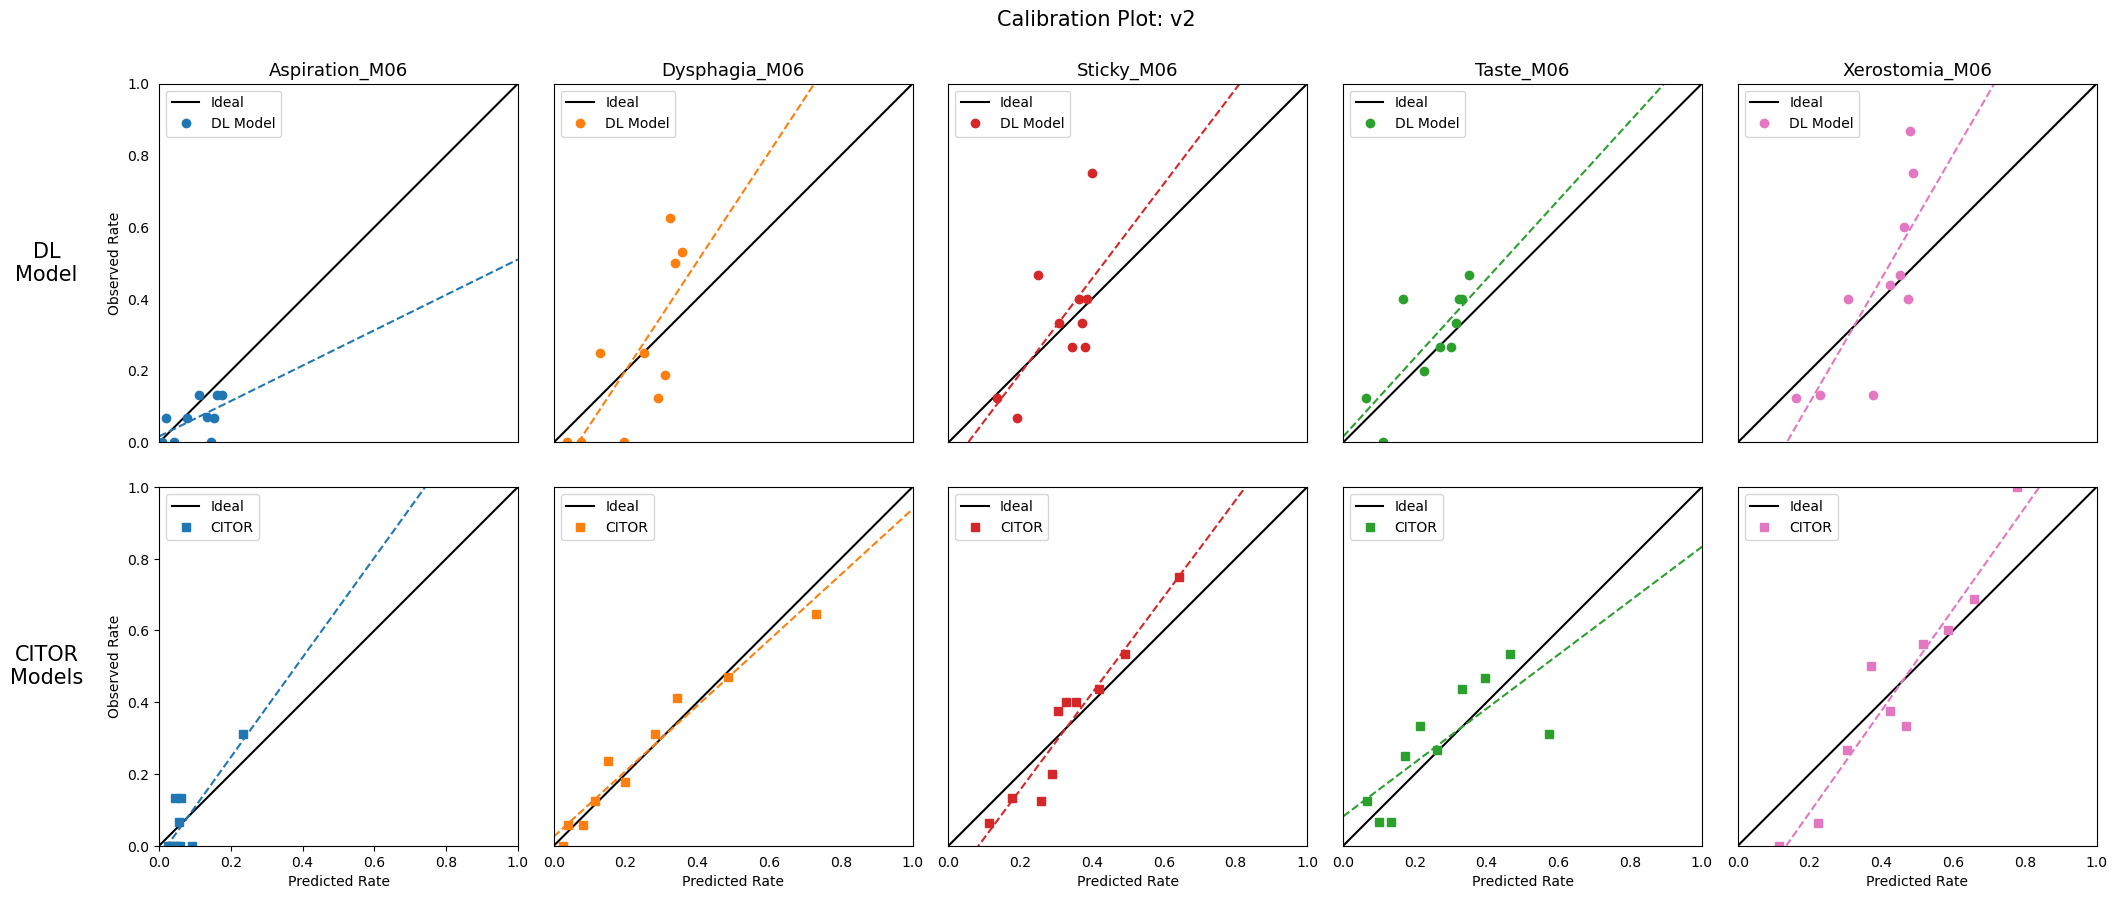

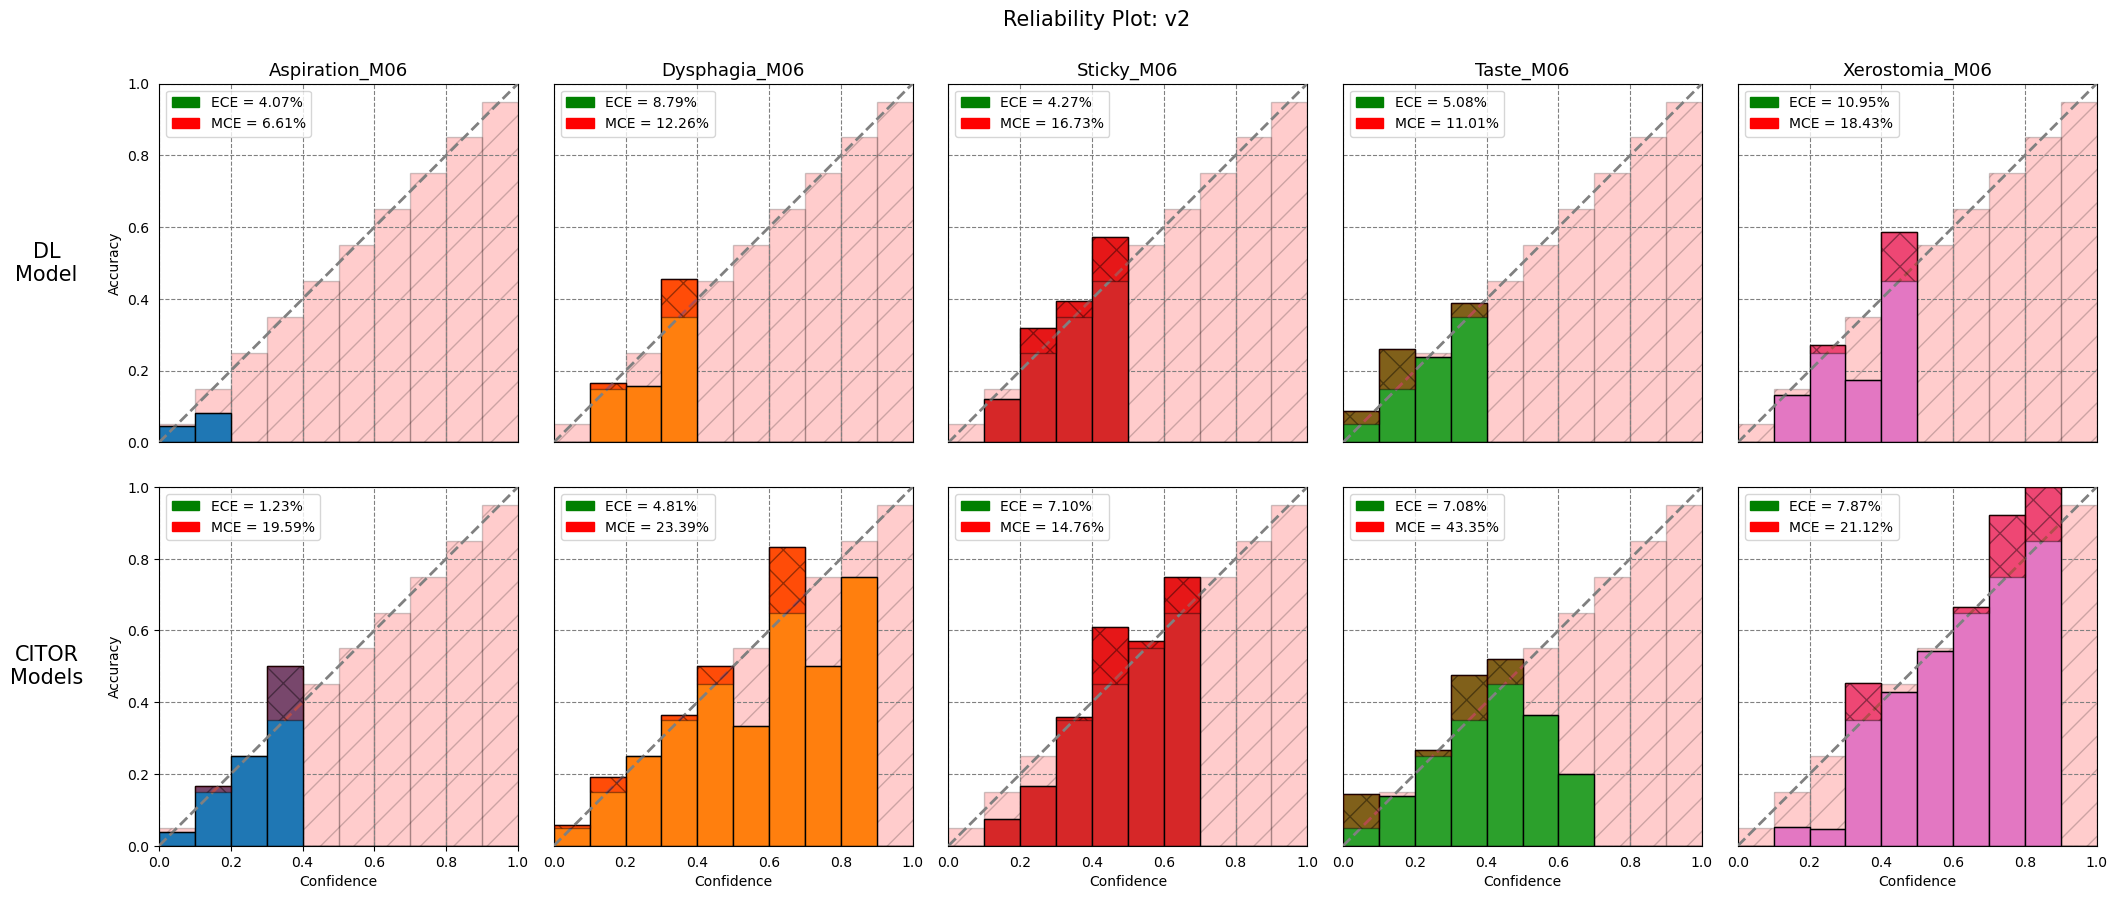

({'Aspiration_M06': 0.041,
  'Dysphagia_M06': 0.088,
  'Sticky_M06': 0.043,
  'Taste_M06': 0.051,
  'Xerostomia_M06': 0.109},
 {'Aspiration_M06': 0.066,
  'Dysphagia_M06': 0.123,
  'Sticky_M06': 0.167,
  'Taste_M06': 0.11,
  'Xerostomia_M06': 0.184},
 {'Aspiration_M06': 0.012,
  'Dysphagia_M06': 0.048,
  'Sticky_M06': 0.071,
  'Taste_M06': 0.071,
  'Xerostomia_M06': 0.079},
 {'Aspiration_M06': 0.196,
  'Dysphagia_M06': 0.234,
  'Sticky_M06': 0.148,
  'Taste_M06': 0.433,
  'Xerostomia_M06': 0.211})

In [62]:
%matplotlib inline
def make_calibration_plots(config, predictions_dict, true_labels_dict, lr_predictions_dict, lr_true_labels_dict, set_name, mode = "calibration", filename=None):
    """
    Makes a calivration plot using a set predicitons and true labels. The predictions are split into 10 bins for this.
    The plot is then saved to a file if a `filename` is provided.
    Args:
        config: a ConfigObject.
        predictions_dict: a dictionary of lists of predictions for each endpoint.
        true_labels_dict: a dictionary of lists of true labels for each endpoint.
        set_name: a string, the name of the set (e.g. 'train', 'val', 'test') to be used in the title of the plot.
        filename: a string, the name of the file to save the plot to.
    Returns:
        None
    """
    colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']
    #colours = ['blue', 'orange', 'red', 'green', 'magenta', 'darkviolet', 'saddlebrown', 'cyan']

    DL_ECE = {}
    DL_MCE = {}
    LR_ECE = {}
    LR_MCE = {}


    num_endpoints = len(config.endpoint_list)
    row_count = 2
    fig_width = 5 * num_endpoints 
    fig_height = 5 * row_count

    # Create a gridspec to add a colorbar axis
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(
        row_count,
        num_endpoints,
        width_ratios=[1] * num_endpoints,
        hspace=0.1,
        wspace=0.1,
        figure=fig,
    )

    # Create title
    if mode == "calibration":
        title = "Calibration Plot: {}".format(set_name)
        x_axis_label = "Predicted Rate"
        y_axis_label = "Observed Rate"
        
    elif mode == "reliability":
        title = "Reliability Plot: {}".format(set_name)
        x_axis_label = "Confidence"
        y_axis_label = "Accuracy"
    else:
        raise ValueError("Calibration plotting mode must be either `calibration` or `reliability`")
    
    fig.suptitle(title, fontsize=15, y=0.95)

    # Create subplots
    axs = [
        [plt.subplot(gs[i, j]) for j in range(num_endpoints)] for i in range(row_count)
    ]

    labels = ["DL\nModel", "CITOR\nModels"]

    for i in range(row_count):
        for j in range(num_endpoints):
            axs[i][j].set_aspect("equal")
            if i != row_count - 1:
                axs[i][j].set_xticklabels([])
                axs[i][j].set_frame_on(True)
                axs[i][j].tick_params(tick1On=False)
            else:
                axs[i][j].set_xlabel(x_axis_label)
            
            if j != 0:
                axs[i][j].set_yticklabels([])
                axs[i][j].set_frame_on(True)
                axs[i][j].tick_params(tick1On=False)
            else:
                axs[i][j].set_ylabel(y_axis_label)
                axs[i][j].annotate(
                    labels[i],
                    xy=(0, 0.5),
                    xytext=(-axs[i][j].yaxis.labelpad - 40, 0),
                    xycoords=axs[i][j].yaxis.label,
                    textcoords="offset points",
                    size=15,
                    ha="center",
                    va="center",
                )

            axs[i][j].set_xlim(0, 1)
            axs[i][j].set_ylim(0, 1)


    for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
        ax.set_title(endpoint, fontdict={'fontsize': 13})

        if mode == "calibration":
            calibration_subplot(config, ax, predictions_dict[endpoint], true_labels_dict[endpoint], color=colours[idx], DL_model=True)
        elif mode == "reliability":
            ece, mce = draw_reliability_subplot(config, ax, predictions_dict[endpoint], true_labels_dict[endpoint], color=colours[idx], DL_model=True)
            DL_ECE[endpoint] = ece
            DL_MCE[endpoint] = mce
        
    for idx, (ax, endpoint) in enumerate(zip(axs[1], config.endpoint_list)):
        if mode == "calibration":
            calibration_subplot(config, ax, lr_predictions_dict[endpoint], lr_true_labels_dict[endpoint], color=colours[idx], DL_model=False)
        elif mode == "reliability":
            ece, mce = draw_reliability_subplot(config, ax, lr_predictions_dict[endpoint], lr_true_labels_dict[endpoint], color=colours[idx], DL_model=False)
            LR_ECE[endpoint] = ece
            LR_MCE[endpoint] = mce

    if filename is not None:
        plt.savefig(filename)
    plt.show()

    return DL_ECE, DL_MCE, LR_ECE, LR_MCE





def calc_bins(y_pred, y_true, num_bins = 10):
    # Assign each prediction to a bin
    bins = np.linspace(0.1, 1, num_bins)
    binned = np.digitize(y_pred, bins, right=True)
    #unique, counts = np.unique(binned, return_counts=True)

    # Save the accuracy, confidence and size of each bin
    bin_accs = np.zeros(num_bins)
    bin_confs = np.zeros(num_bins)
    bin_sizes = np.zeros(num_bins)
    labels_oneh = y_true
    for bin in range(num_bins):
        bin_sizes[bin] = len(y_pred[binned == bin])
        if bin_sizes[bin] > 0:
            bin_accs[bin] = (labels_oneh[binned==bin]).sum() / bin_sizes[bin]
            bin_confs[bin] = (y_pred[binned==bin]).sum() / bin_sizes[bin]

    return bins, binned, bin_accs, bin_confs, bin_sizes


def get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes):
    """
    Calculates the ECE and MCE metrics for a set of bins.
    """
    ECE = 0
    MCE = 0

    for i in range(len(bins)):
        abs_conf_dif = abs(bin_accs[i] - bin_confs[i])
        ECE += (bin_sizes[i] / sum(bin_sizes)) * abs_conf_dif
        MCE = max(MCE, abs_conf_dif)

    return ECE, MCE


import matplotlib.patches as mpatches



def calibration_subplot(config, ax, y_pred, y_true, color, DL_model = True, n_bins=10):
    """
    Draws the UMCG-style calibration plot
    """
    x = [0,1]
    y = [0,1]

    mask = [True if x in config.valid_endpoint_values else False for x in y_true]

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=n_bins, strategy="quantile")

    coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
    linear_fit = np.poly1d(coef)

    # plot the points (scatter)
    shape = 'o' if DL_model else 's'
    label = "DL Model" if DL_model else "CITOR"

    ax.plot([0, 1], [0, 1], "black", label="Ideal") # plot the ideal line

    ax.plot(mean_predicted_value, fraction_of_positives, shape, label=label, color=color)
    # plot the best fit line
    ax.plot(x, linear_fit(y), '--',   color=color)
    
    ax.legend()



def draw_reliability_subplot(config, ax, y_pred, y_true, color, DL_model = True, n_bins=10):
    """
    Draws the ECE reliability subplot for a set of predictions and true labels.
    """
    mask = [True if x in config.valid_endpoint_values else False for x in y_true]

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(y_pred, y_true, num_bins=n_bins)

    ECE, MCE = get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes)

    bin_centers = bins - 0.05

    # Error bars (light red bars)
    ax.bar(bin_centers, bin_centers,  width=0.1, alpha=0.2, edgecolor='black', color='r', hatch='/', zorder=1)

    # Draw (blue) bars and identity line
    ax.bar(bin_centers, bin_accs, width=0.1, alpha=1, edgecolor='black', color=color, zorder=2)
    ax.plot([0,1],[0,1], '--', color='gray', linewidth=2, zorder=3)

    # ECE and MCE legend
    ECE_patch = mpatches.Patch(color='green', label='ECE = {:.2f}%'.format(ECE*100))
    MCE_patch = mpatches.Patch(color='red', label='MCE = {:.2f}%'.format(MCE*100))
    ax.legend(handles=[ECE_patch, MCE_patch])

    # Create grid
    ax.grid(True, color='gray', linestyle='dashed', zorder=0)

    # plot gaps
    gaps = (bin_accs - bin_centers) 
    gaps = np.clip(gaps, 0, 1)

    #gaps = gaps if gaps > 0 else 0
    ax.bar(bin_centers, gaps, bottom = np.minimum(bin_accs, (bins-0.05)),
                width=0.1, alpha=0.4, edgecolor='black', color='r', hatch='\\/', zorder=3)
    
    ECE = round(ECE, config.nr_of_decimals)
    MCE = round(MCE, config.nr_of_decimals)

    return ECE, MCE



make_calibration_plots(cfg, preds_dict, true_dict, lr_preds_dict, lr_true_dict, mode='calibration', set_name="v2")

make_calibration_plots(cfg, preds_dict, true_dict, lr_preds_dict, lr_true_dict, mode='reliability', set_name="v2")



In [5]:
experiment_dir = "experiments/"

experiment_names = ["neither_augs", "only_first_aug", "only_augmix", "both_augs"]
colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']


for experiment_name in experiment_names:
    exp_path = os.path.join(experiment_dir, experiment_name)

    fold_folders = os.listdir(exp_path)
    x = [0, 1]
    y = [0, 1]

    for folder in fold_folders:
        ax = plt.gca()
        if folder.split("_")[2] == '5':  # if its the fifth folder
            #print(folder)
            path = os.path.join(exp_path, folder)

            df_ens_preds = pd.read_csv(os.path.join(path, "dcnn_lrelu_ens_outputs.csv"), delimiter=";")

            for idx, endpoint in enumerate(cfg.endpoint_list):
                y_true = df_ens_preds[endpoint + "_true"]
                y_pred = df_ens_preds[endpoint + "_pred"]
                
                mask = [True if x in cfg.valid_endpoint_values else False for x in y_true]

                y_true = y_true[mask]
                y_pred = y_pred[mask]

                #y_pred = 1 / (1 + np.exp(-y_pred))

                #print(y_true)


                fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=10, strategy="quantile")

                coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
                linear_fit = np.poly1d(coef)

                #color = next(ax._get_lines.prop_cycler)['color']

                plt.plot(mean_predicted_value, fraction_of_positives, 'o',label=endpoint, color=colours[idx])
                plt.plot(x, linear_fit(y), '--',  color=colours[idx])

                #plt.plot(regre)
                #print(fraction_of_positives)

                #plt.scatter(mean_predicted_value, fraction_of_positives, label=endpoint)
            plt.plot([0,1], [0,1], 'black')
            plt.title(experiment_name)
            plt.legend()
            plt.xlim(0, 1)
            plt.ylim(0, 1)
            plt.show()
            #df_test_preds = df_preds[df_preds["Split"] == "test"]

            

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'experiments/neither_augs'

In [12]:
cfg.endpoint_list

['Aspiration_M06',
 'Dysphagia_M06',
 'Sticky_M06',
 'Taste_M06',
 'Xerostomia_M06']

In [12]:
y, x = calibration_curve(y_true, y_pred, n_bins=10)

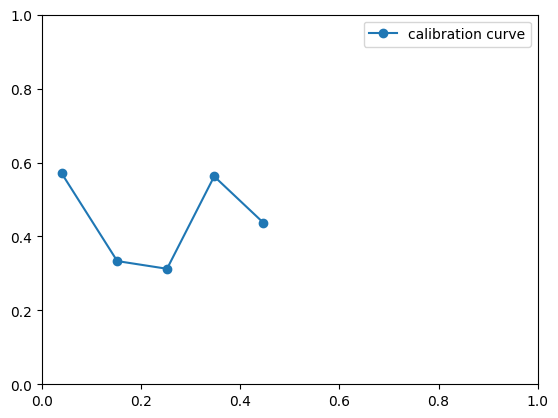

In [14]:

plt.plot(x, y, marker='o', label='calibration curve')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()